# Introduction

In this notebook we will look at some techniques for differential cell abundance analysis when you have multiple samples.

# Load packages

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc

In [2]:
import matplotlib.pyplot as plt

# Load example data

In [3]:
# Day-2 data lives next to the notebooks, in notebooks/day_2/data/.
#
# clean_myeloid.h5ad is the presenters' own dataset and is not public. If it is
# in that folder we use it; otherwise we fall back to Haber et al. 2017 (mouse
# small intestine, the dataset the Milo paper itself uses), remapped onto the
# same column names so every cell below runs unchanged.
from pathlib import Path

DATA = Path("data")
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

myeloid_h5ad = DATA / "clean_myeloid.h5ad"

if myeloid_h5ad.exists():
    adata = sc.read_h5ad(myeloid_h5ad)
else:
    print(f"{myeloid_h5ad} not found - falling back to public Haber 2017 data")
    import pertpy as pt

    adata = pt.dt.haber_2017_regions()
    adata = adata[adata.obs["condition"].isin(["Control", "Salmonella"])].copy()
    adata.obs["condition"] = (
        adata.obs["condition"].map({"Control": "CTRL", "Salmonella": "DT"}).astype("category")
    )
    adata.obs["SampleID"] = adata.obs["batch"].astype(str)
    adata.obs["Celltype_myeloid"] = adata.obs["cell_label"]
    adata.layers["norm_count"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.layers["norm_log"] = adata.X.copy()
    sc.pp.pca(adata, n_comps=50)
    sc.pp.neighbors(adata)
    sc.tl.tsne(adata)

adata

AnnData object with n_obs × n_vars = 4718 × 12786
    obs: 'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid'
    obsm: 'X_pca', 'X_tsne', 'imputed_data'
    layers: 'norm_count', 'norm_log', None (.X)

In [4]:
adata

AnnData object with n_obs × n_vars = 4718 × 12786
    obs: 'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid'
    obsm: 'X_pca', 'X_tsne', 'imputed_data'
    layers: 'norm_count', 'norm_log', None (.X)

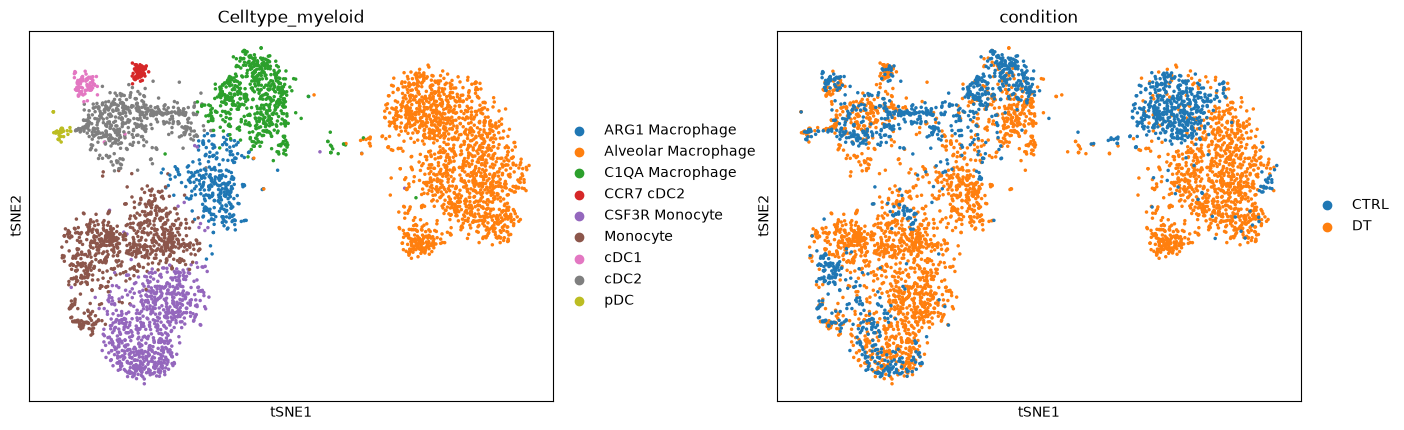

In [5]:
sc.pl.tsne(adata, color=["Celltype_myeloid", "condition"], wspace=0.3)

## Alternate visual

Let's visualize density differences based on distribution of cells on the tSNE space. This gives was a visual perspective of what the density differences look like:

In [6]:
df_temp = pd.DataFrame(
    {
        "tsne_x": adata.obsm["X_tsne"][:, 0],
        "tsne_y": adata.obsm["X_tsne"][:, 1],
        "condition": adata.obs["condition"],
    },
    index=adata.obs.index,
)

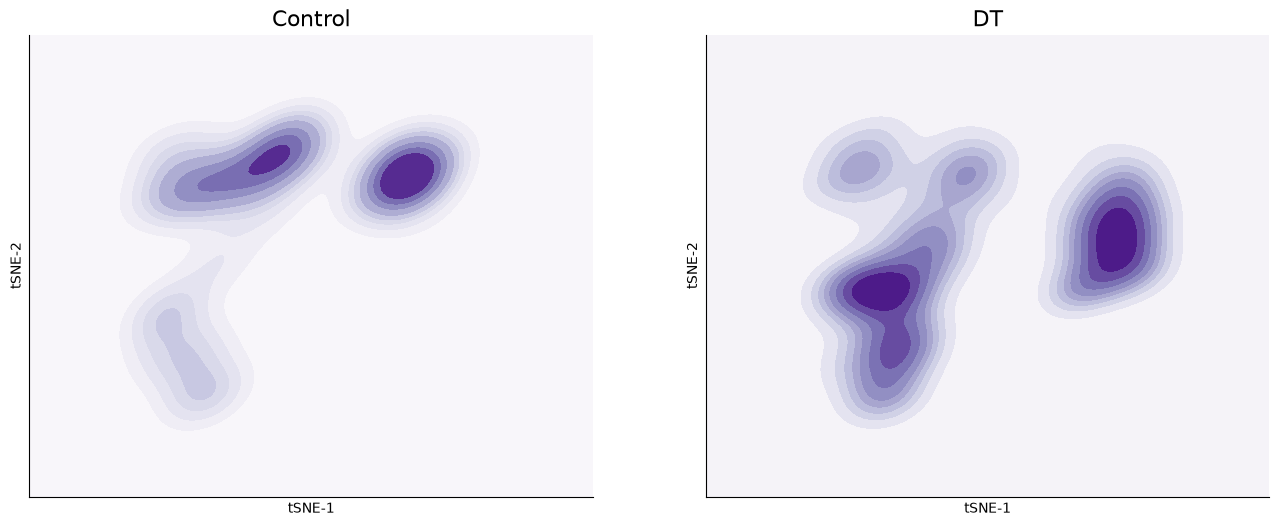

In [7]:
import seaborn as sns

fig = plt.figure(figsize=(8 * 2, 6))
ax = fig.add_subplot(1, 2, 1)
sns.scatterplot(data=df_temp, x="tsne_x", y="tsne_y", s=1, ax=ax)
sns.kdeplot(
    data=df_temp[df_temp["condition"] == "CTRL"],
    x="tsne_x",
    y="tsne_y",
    fill=True,
    thresh=0,
    levels=10,
    cmap="Purples",
    ax=ax,
    cut=4,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Control", fontsize=16)
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax = fig.add_subplot(1, 2, 2)
sns.scatterplot(data=df_temp, x="tsne_x", y="tsne_y", s=0, ax=ax)
sns.kdeplot(
    data=df_temp[df_temp["condition"] == "DT"],
    x="tsne_x",
    y="tsne_y",
    fill=True,
    thresh=0,
    levels=10,
    cmap="Purples",
    ax=ax,
    cut=4,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("DT", fontsize=16)
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
# fig.savefig(outbase + 'Ctrl_DT_kdeplot_endo.png', dpi = 150, bbox_inches = 'tight')

# MiloR

Milo is a statistical method to quantify changes in cellular abundancies in neighborhoods of cells in high-dimensional space. Given a data with cells from two conditions, Milo partitions the cell phenotype space in a set of (possibly overlapping) neighborhoods and allows quantification of differential abundances of cells from one condition compared to another in each neighborhood. It outputs associated logfoldchange between the two conditions, p-values and multiple comparisons adjusted p-values for each neighborhood. Furthermore, Milo allows one to annotate each neighborhood as a distinct celltype based on the proportion of cells from each celltype in the neighborhood. All of this is discussed in the code below. 

Milo's strength lies in detecting subtle `local` changes in cellular abundances. This is possible by the use of graphs and looking for changes in occupancy locally along the graph. 

For more details, please see the original publication: https://www.nature.com/articles/s41587-021-01033-z.

We will use the pertpy implementation of miloR from Python.

MiloR has been included in the more general perturbation analysis package called Pertpy: https://github.com/scverse/pertpy

## Import and setup pertpy

In [8]:
import pertpy as pt

milo = pt.tl.Milo()
# Create a milo object - note: milor requires mudata as input
mdata = milo.load(adata)

In [9]:
# compute neighbor graph
sc.pp.neighbors(mdata["rna"], n_neighbors=30, use_rep="X_pca")

In [10]:
# Make overlapping neighborhoods
milo.make_nhoods(
    mdata["rna"], neighbors_key=None, feature_key="rna", prop=0.1, seed=0, copy=False
)

In [11]:
# count cells in each neighborhood
mdata = milo.count_nhoods(mdata, sample_col="SampleID")

In [12]:
# Do differential abundance analysis using milo
milo.da_nhoods(mdata, design="~condition")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.07 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition DT vs CTRL
     baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0    2.743785        2.120681  1.191181  1.780319  0.075024  0.134118
1    1.669127        3.343144  1.551531  2.154739  0.031182  0.070483
2    1.143244        2.280377  1.492123  1.528276  0.126444       NaN
3    1.805449        0.337560  1.050503  0.321332  0.747959  0.821832
4    2.736624       -0.206659  1.037876 -0.199117  0.842171  0.886719
..        ...             ...       ...       ...       ...       ...
319  4.444410       -3.939028  1.646968 -2.391685  0.016771  0.049879
320  5.766262       -4.231769  1.048890 -4.034523  0.000055  0.002856
321  1.284967       -0.382013  1.246316 -0.306513  0.759214       NaN
322  2.103219       -3.175991  1.181118 -2.688971  0.007167  0.032765
323  1.898777       -1.601053  1.097281 -1.459110  0.144535  0.220606

[324 rows x 6 columns]


... done in 0.10 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.09 seconds.



In [13]:
mdata["rna"]

AnnData object with n_obs × n_vars = 4718 × 12786
    obs: 'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    uns: 'Celltype_myeloid_colors', 'condition_colors', 'neighbors', 'nhood_neighbors_key'
    obsm: 'X_pca', 'X_tsne', 'imputed_data', 'nhoods'
    obsp: 'distances', 'connectivities'
    layers: 'norm_count', 'norm_log', None (.X)

## Visualize fold change on UMAP/tSNE

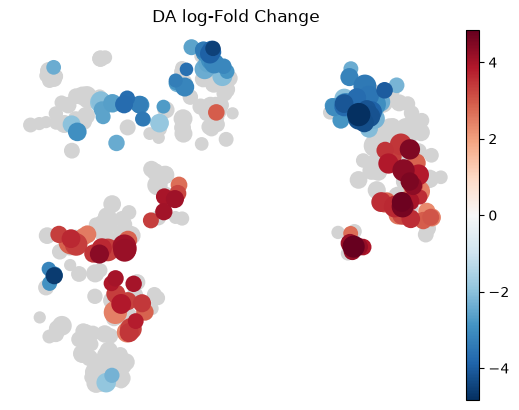

In [14]:
# Build graph and visualize it
milo.build_nhood_graph(mdata, basis="X_tsne")
milo.plot_nhood_graph(mdata)

In [15]:
mdata["rna"]

AnnData object with n_obs × n_vars = 4718 × 12786
    obs: 'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    uns: 'Celltype_myeloid_colors', 'condition_colors', 'neighbors', 'nhood_neighbors_key'
    obsm: 'X_pca', 'X_tsne', 'imputed_data', 'nhoods'
    obsp: 'distances', 'connectivities'
    layers: 'norm_count', 'norm_log', None (.X)

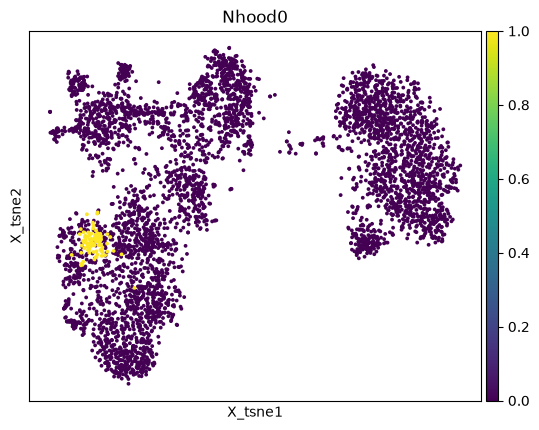

In [16]:
# Highlight a specific neighborhood
milo.plot_nhood(mdata, ix=0, basis="X_tsne")

## Visualize results as a beeswarm plot

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_48687/2246118558.py:2: FutureWarning: The argument alpha is deprecated and will be removed in the future. Use `padj_threshold`.
  milo.plot_da_beeswarm(mdata, alpha=0.05)


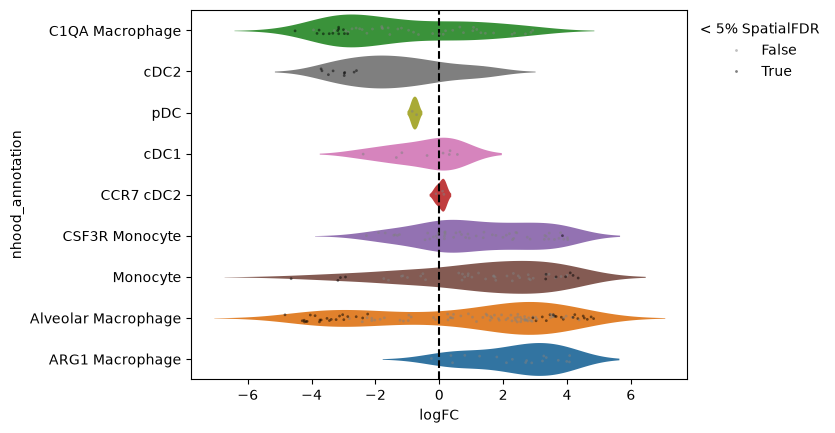

In [17]:
milo.annotate_nhoods(mdata, anno_col="Celltype_myeloid")
milo.plot_da_beeswarm(mdata, alpha=0.05)

In [18]:
mdata["rna"]

AnnData object with n_obs × n_vars = 4718 × 12786
    obs: 'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'Nhood'
    uns: 'Celltype_myeloid_colors', 'condition_colors', 'neighbors', 'nhood_neighbors_key'
    obsm: 'X_pca', 'X_tsne', 'imputed_data', 'nhoods'
    obsp: 'distances', 'connectivities'
    layers: 'norm_count', 'norm_log', None (.X)

## Alternate beeswarm visual

In [19]:
mdata["milo"]

AnnData object with n_obs × n_vars = 11 × 324
    obs: 'condition', 'SampleID'
    var: 'index_cell', 'kth_distance', 'logCPM', 'logFC', 'PValue', 'FDR', 'SpatialFDR', 'Nhood_size', 'nhood_annotation', 'nhood_annotation_frac'
    uns: 'sample_col', 'da_nhoods_columns', 'nhood', 'annotation_labels', 'annotation_obs'
    varm: 'X_milo_graph', 'frac_annotation'
    varp: 'nhood_connectivities'
    layers: None (.X)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_48687/612319596.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_yticklabels(cbar.ax.get_yticks(), fontsize=18)
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_48687/612319596.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_yticklabels(cbar.ax.get_yticks(), fontsize=18)
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_48687/612319596.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_yticklabels(cbar.ax.get_yticks(), fontsize=18)


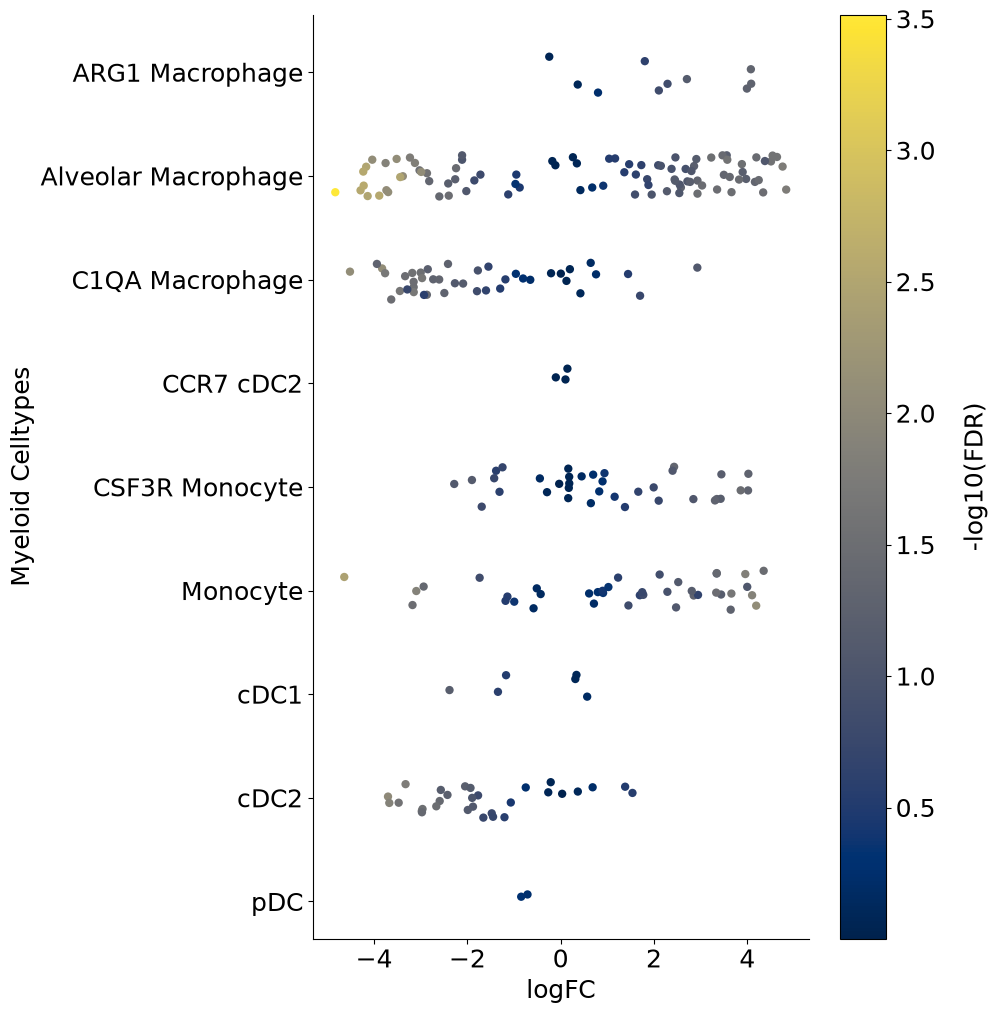

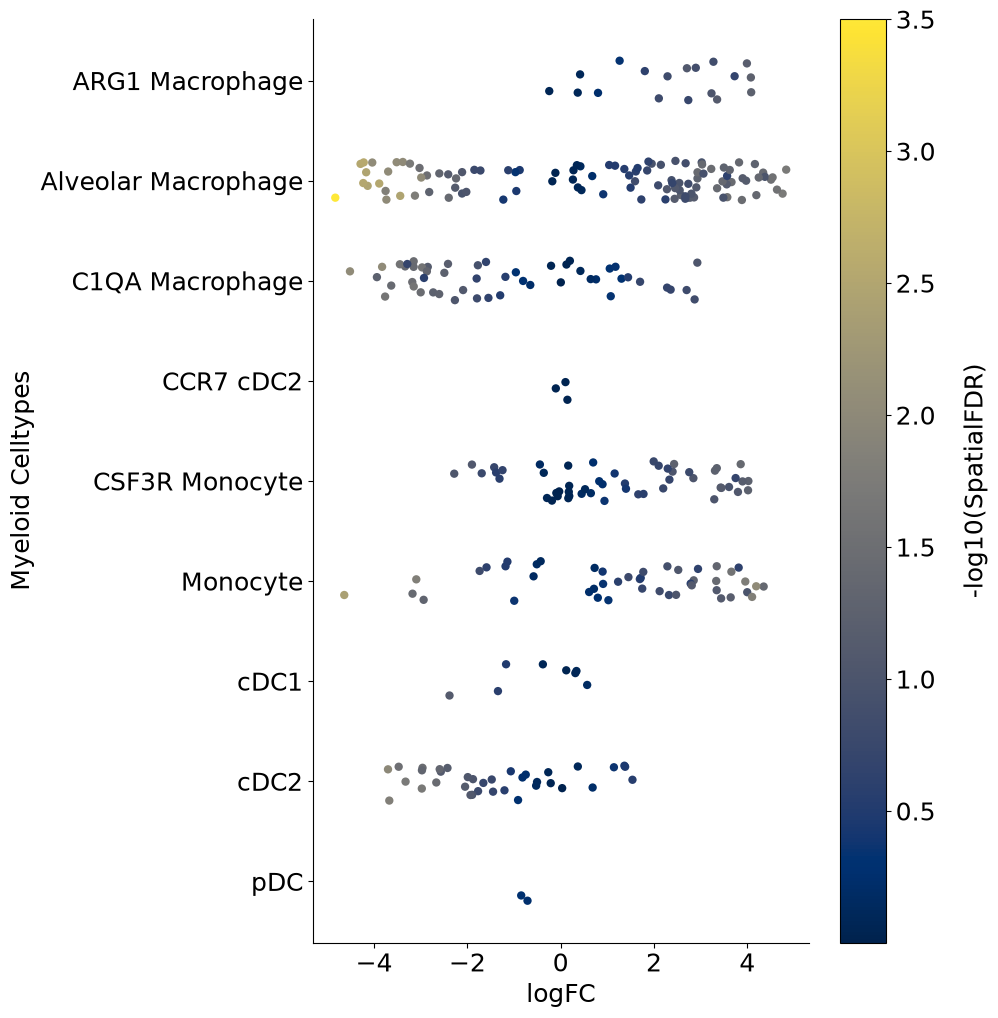

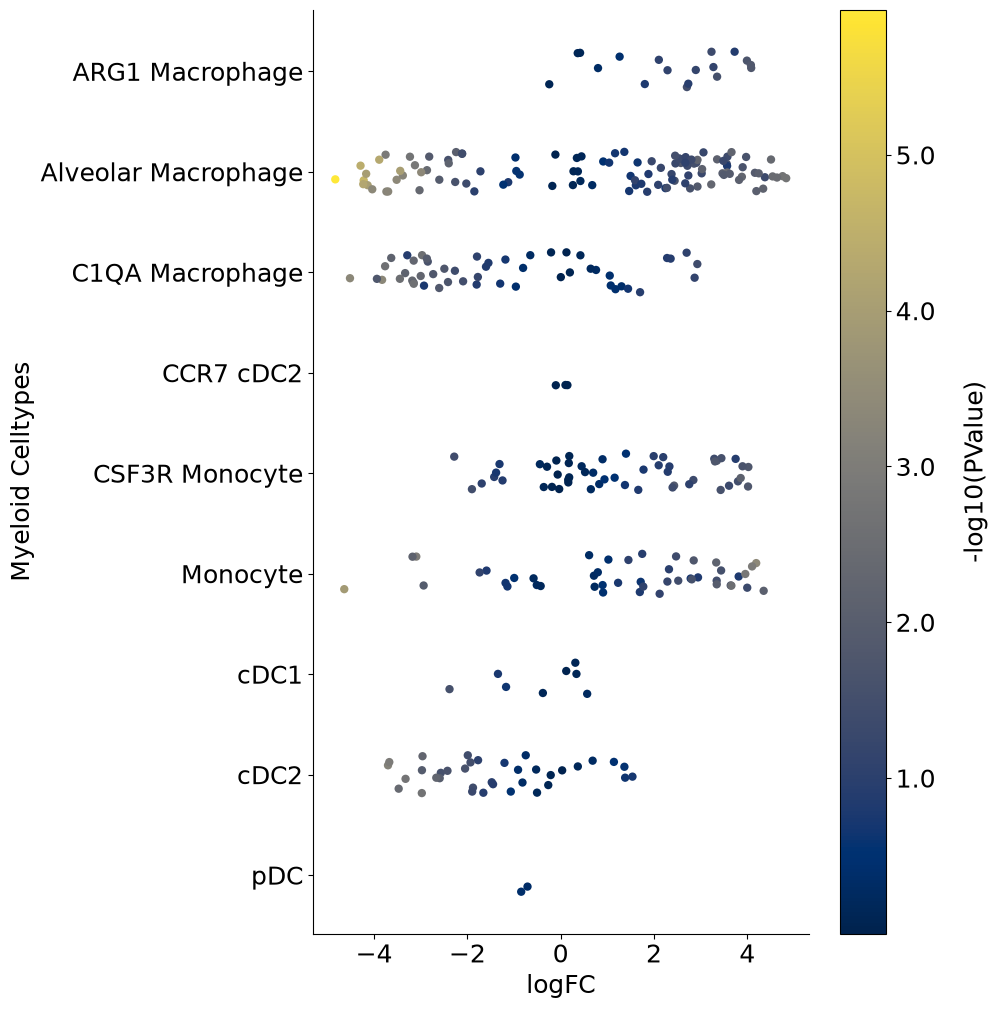

In [20]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

outbase = "outputs/"

for j, item in enumerate(["FDR", "SpatialFDR", "PValue"]):
    fig = plt.figure(figsize=(8, 12))
    mdata["milo"].var["log_" + item] = -np.log10(mdata["milo"].var[item])
    ax = fig.add_subplot(1, 1, 1)
    plot = sns.stripplot(
        x="logFC",
        y="nhood_annotation",
        hue="log_" + item,
        data=mdata["milo"].var,
        size=6,
        palette="cividis",
        jitter=0.2,
        edgecolor="none",
        ax=ax,
    )
    plot.get_legend().set_visible(False)
    # ax.set_xticklabels(ax.get_xticks(), fontsize = 18)
    # ax.set_yticklabels(ax.get_yticks(), fontsize = 18)
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.set_ylabel("Myeloid Celltypes", fontsize=18)
    ax.set_xlabel("logFC", fontsize=18)
    sns.despine()

    # Drawing the side color bar
    normalize = mcolors.Normalize(
        vmin=mdata["milo"].var["log_" + item].min(),
        vmax=mdata["milo"].var["log_" + item].max(),
    )
    colormap = cm.cividis

    for n in mdata["milo"].var["log_" + item]:
        plt.plot(color=colormap(normalize(n)))

    scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
    scalarmappaple.set_array(mdata["milo"].var["log_" + item])
    cbar = fig.colorbar(scalarmappaple, ax=plt.gca())
    cbar.ax.set_yticklabels(cbar.ax.get_yticks(), fontsize=18)
    cbar.ax.set_ylabel("-log10(" + item + ")", labelpad=20, rotation=90, fontsize=18)
    ax.grid(False)
    # fig.savefig(outbase + 'milor_myeloid_swarmplot_colored_by_log_' + item + '.pdf', dpi = 300,
    #            bbox_inches = 'tight')

## Adding contrasts

So far we compared the two conditions directly. Often the design is richer than
that: several groups, and a specific comparison you care about.

To show what a contrast does - and what it looks like when there is nothing to
find - we split the samples into three groups. **A** and **B** are both control
samples, **C** are the treated ones. So `A - B` compares like with like and
should come up empty, while `C - (A + B) / 2` should recover the real signal.

In [21]:
# A/B are both control samples, C are the treated ones.
map_dictionary = {
    "2_ctl_1_CD45minus": "B",
    "2_ctl_1_CD45plus": "B",
    "2_ctl_2_CD45plus": "A",
    "2_ctl_3_CD45plus": "A",
    "ctl_3_CD45_minus": "A",
    "2_DT_1_CD45_minus": "C",
    "2_DT_1_CD45plus": "C",
    "2_DT_2_CD45minus": "C",
    "2_DT_2_CD45plus": "C",
    "2_DT_3_CD45_minus": "C",
    "2_DT_3_CD45plus": "C",
}

if not set(adata.obs["SampleID"]).issubset(map_dictionary):
    # fallback dataset: same idea, built from whatever samples it has
    ctrl = sorted(adata.obs.loc[adata.obs["condition"] == "CTRL", "SampleID"].unique())
    dt = sorted(adata.obs.loc[adata.obs["condition"] == "DT", "SampleID"].unique())
    map_dictionary = {s: "AB"[i % 2] for i, s in enumerate(ctrl)}
    map_dictionary.update({s: "C" for s in dt})

adata.obs["random_assignment"] = adata.obs["SampleID"].map(map_dictionary).astype("category")
adata.obs[["SampleID", "condition", "random_assignment"]].drop_duplicates()

,SampleID,condition,random_assignment
120703424032052000,2_DT_1_CD45_minus,DT,C
121826186746205001,2_DT_1_CD45plus,DT,C
121955419016036002,2_DT_2_CD45minus,DT,C
120703424257380003,2_DT_2_CD45plus,DT,C
134592140302124004,2_DT_3_CD45_minus,DT,C
120703423539997005,2_DT_3_CD45plus,DT,C
135014267898229006,2_ctl_1_CD45minus,CTRL,B
120703409384348007,2_ctl_1_CD45plus,CTRL,B
120703424088364009,2_ctl_2_CD45plus,CTRL,A
120703409575734010,2_ctl_3_CD45plus,CTRL,A


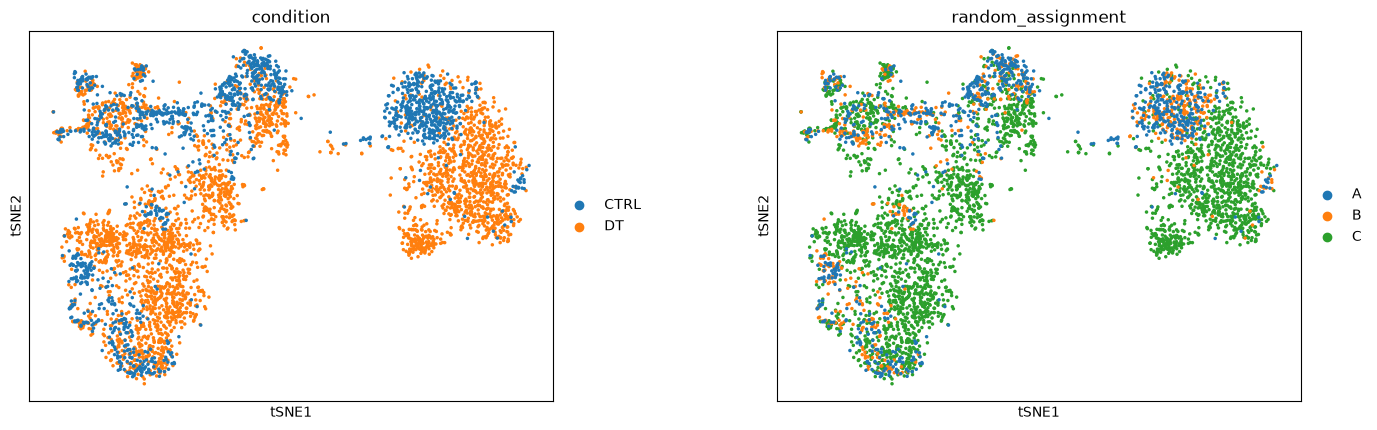

In [22]:
sc.pl.tsne(adata, color=["condition", "random_assignment"], wspace=0.3)

Build a second Milo object on the same cells, this time carrying the A/B/C
labels.

In [23]:
mdata2 = milo.load(adata)
sc.pp.neighbors(mdata2["rna"], n_neighbors=30, use_rep="X_pca")
milo.make_nhoods(mdata2["rna"], neighbors_key=None, feature_key="rna", prop=0.1, seed=0, copy=False)
mdata2 = milo.count_nhoods(mdata2, sample_col="SampleID")
mdata2

MuData object with n_obs × n_vars = 4718 × 12786
  2 modalities
    rna:	4718 × 12786
      obs:	'Clusters', 'Celltype', 'SampleID', 'name', 'background', 'condition', 'replicate', 'experiment', 'ncells', 'libsize', 'mito_fraction', 'ribo_fraction', 'mhc_fraction', 'actin_fraction', 'cytoskeleton_fraction', 'malat1_fraction', 'scrublet_predict', 'scrublet_score', 'lowlibsize', 'Clusters_myeloid', 'Celltype_myeloid', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'Nhood', 'random_assignment'
      uns:	'Celltype_myeloid_colors', 'condition_colors', 'neighbors', 'nhood_neighbors_key', 'random_assignment_colors'
      obsm:	'X_pca', 'X_tsne', 'imputed_data', 'nhoods'
      layers:	'norm_count', 'norm_log', None
      obsp:	'distances', 'connectivities'
    milo:	11 × 324
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'
      layers:	None

### A vs B - two sets of control samples

`model_contrasts` takes the same string syntax as R's miloR. `add_intercept=False`
is the equivalent of writing `~ 0 + random_assignment` in the R formula.

In [24]:
milo.da_nhoods(
    mdata2,
    design="~random_assignment",
    add_intercept=False,
    model_contrasts="random_assignmentA - random_assignmentB",
)

da_A_B = mdata2["milo"].var.copy()
da_A_B.head()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.08 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...


Using None as control genes, passed at DeseqDataSet initialization
Log2 fold change & Wald test p-value: random_assignment A vs B
     baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0    2.743785        0.200596  2.128838  0.094228  0.924928  0.997342
1    1.669127        0.862587  3.044444  0.283332  0.776923  0.997342
2    1.143244        1.455540  3.006817  0.484080  0.628329  0.997342
3    1.805449        0.088761  1.804606  0.049186  0.960771  0.997342
4    2.736624        2.268858  1.845642  1.229305  0.218957  0.997342
..        ...             ...       ...       ...       ...       ...
319  4.444410        1.894546  1.607731  1.178397  0.238638  0.997342
320  5.766262        0.857446  1.408343  0.608833  0.542635  0.997342
321  1.284967       -0.451565  2.068447 -0.218311  0.827187  0.997342
322  2.103219       -0.005259  1.693815 -0.003105  0.997523  0.997523
323  1.898777        0.782211  1.770404  0.441826  0.658615  0.997342

[324 rows x 6 columns]


... done in 0.07 seconds.

Fitting LFCs...
... done in 0.08 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.08 seconds.



,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,120703455259875000,19.622087,2.743785,0.200596,0.924928,0.997342,0.996811
1,121202296338285000,21.291719,1.669127,0.862587,0.776923,0.997342,0.996811
2,121742702860188000,32.064745,1.143244,1.455540,0.628329,0.997342,0.996811
3,121896067512670000,27.819591,1.805449,0.088761,0.960771,0.997342,0.996811
4,122282776874270000,30.553243,2.736624,2.268858,0.218957,0.997342,0.996811


neighbourhoods with SpatialFDR < 0.1: 0 of 324


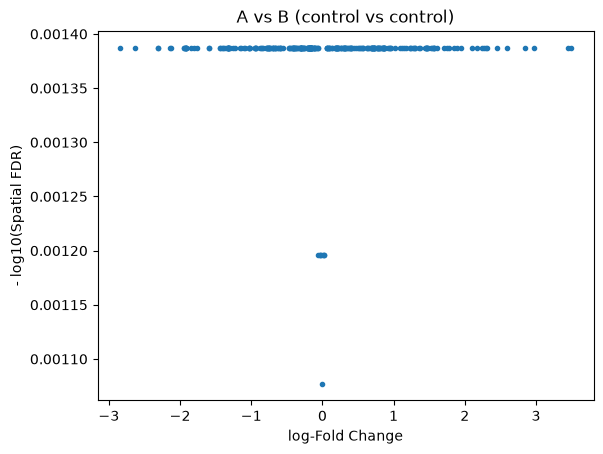

In [25]:
print(f"neighbourhoods with SpatialFDR < 0.1: {(da_A_B['SpatialFDR'] < 0.1).sum()} of {len(da_A_B)}")

plt.plot(da_A_B.logFC, -np.log10(da_A_B.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.title("A vs B (control vs control)")
plt.show()

As expected, comparing control against control finds essentially nothing.

### C vs the two control groups together

In R you would write this as `random_assignmentC - (random_assignmentA +
random_assignmentB)/2`. pertpy's default `pydeseq2` solver only takes simple
pairwise contrasts, so we pool A and B into one level and compare against that.
It answers the same question; the R form is available via `solver="edger"`,
which needs R and edgeR installed.

In [26]:
# pool the two control groups into a single level
mdata2["rna"].obs["control_pooled"] = (
    mdata2["rna"].obs["random_assignment"]
    .map({"A": "AB", "B": "AB", "C": "C"})
    .astype("category")
)

milo.da_nhoods(
    mdata2,
    design="~control_pooled",
    add_intercept=False,
    model_contrasts="control_pooledC - control_pooledAB",
)

da_C_AB = mdata2["milo"].var.copy()
da_C_AB.head()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.08 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...


Log2 fold change & Wald test p-value: control_pooled C vs AB
     baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0    2.743785        2.120681  1.191181  1.780319  0.075024  0.134118
1    1.669127        3.343144  1.551531  2.154739  0.031182  0.070483
2    1.143244        2.280377  1.492123  1.528276  0.126444       NaN
3    1.805449        0.337560  1.050503  0.321332  0.747959  0.821832
4    2.736624       -0.206659  1.037876 -0.199117  0.842171  0.886719
..        ...             ...       ...       ...       ...       ...
319  4.444410       -3.939028  1.646968 -2.391685  0.016771  0.049879
320  5.766262       -4.231769  1.048890 -4.034523  0.000055  0.002856
321  1.284967       -0.382013  1.246316 -0.306513  0.759214       NaN
322  2.103219       -3.175991  1.181118 -2.688971  0.007167  0.032765
323  1.898777       -1.601053  1.097281 -1.459110  0.144535  0.220606

[324 rows x 6 columns]


... done in 0.08 seconds.

Fitting LFCs...
... done in 0.07 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.07 seconds.



,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,120703455259875000,19.622087,2.743785,2.120681,0.075024,0.134118,0.145281
1,121202296338285000,21.291719,1.669127,3.343144,0.031182,0.070483,0.081217
2,121742702860188000,32.064745,1.143244,2.280377,0.126444,NaN,0.204127
3,121896067512670000,27.819591,1.805449,0.337560,0.747959,0.821832,0.822744
4,122282776874270000,30.553243,2.736624,-0.206659,0.842171,0.886719,0.888034


neighbourhoods with SpatialFDR < 0.1: 140 of 324


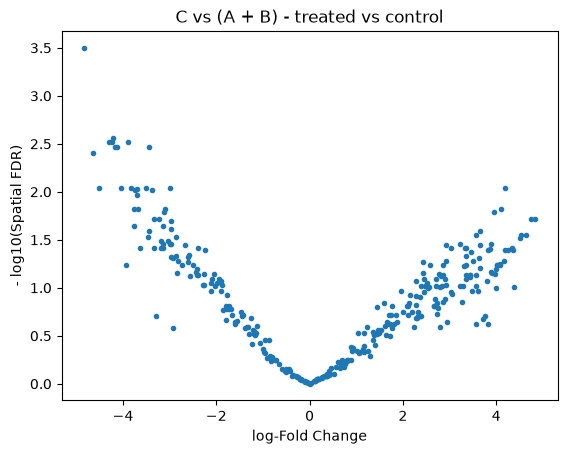

In [27]:
print(f"neighbourhoods with SpatialFDR < 0.1: {(da_C_AB['SpatialFDR'] < 0.1).sum()} of {len(da_C_AB)}")

plt.plot(da_C_AB.logFC, -np.log10(da_C_AB.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.title("C vs (A + B) - treated vs control")
plt.show()

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_48687/3908586166.py:2: FutureWarning: The argument alpha is deprecated and will be removed in the future. Use `padj_threshold`.
  milo.plot_da_beeswarm(mdata2, alpha=0.05)


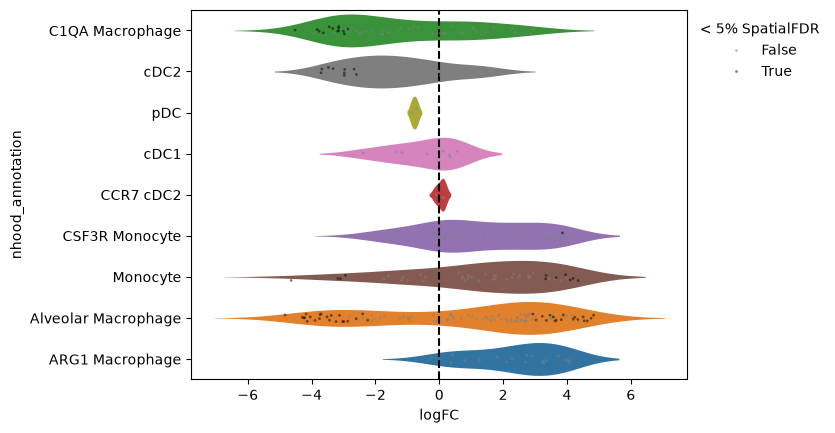

In [28]:
milo.annotate_nhoods(mdata2, anno_col="Celltype_myeloid")
milo.plot_da_beeswarm(mdata2, alpha=0.05)